## Parte 1: Dataset e imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

PyTorch: 2.13.0+cu130
CUDA disponible: True


## Parte 2: Exploración y preparación de los datos

In [3]:
# cargar el dataset

housing = fetch_california_housing(as_frame=True)
df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
# observaciones y variables
print("Tamaño del dataset")
print(df.shape)
print("Columnas del dataset")
print(df.columns.tolist())
print("Información general")
df.info()
print(housing.feature_names)

Tamaño del dataset
(20640, 9)
Columnas del dataset
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
Información general
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [9]:
# revision de nulos, duplicados y atípicos

print("NULOS")
print(df.isnull().sum())
print("DUPLICADOS")
print(df.duplicated().sum())
print("ESTADÍSTICAS")
df.describe()

NULOS
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
DUPLICADOS
0
ESTADÍSTICAS


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


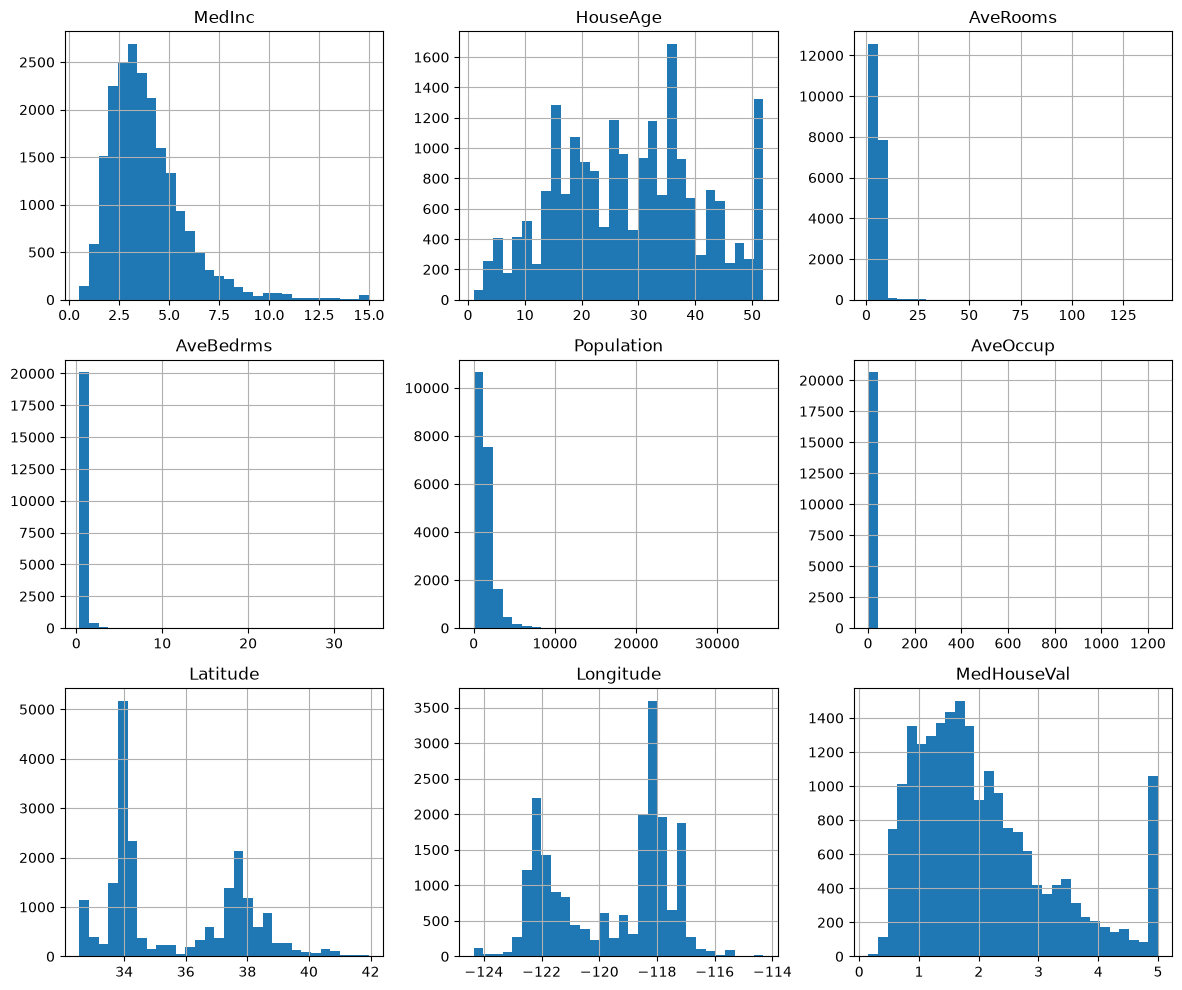

In [10]:
df.hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()

In [ ]:
# separación train / val / test: (60% / 20% / 20%)

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(12384, 8) (4128, 8) (4128, 8)


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Respuestas — Parte 2

**¿Cuántas observaciones y cuántas variables tiene el dataset?**

El dataset tiene **20 640 observaciones** y **9 columnas** en total: **8 features** (`MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`) y **1 variable objetivo** (`MedHouseVal`).

**¿Qué representa cada variable y cuál es el target?**

| Variable | Significado |
|---|---|
| `MedInc` | Ingreso mediano del bloque (en decenas de miles de USD) |
| `HouseAge` | Edad mediana de las viviendas del bloque |
| `AveRooms` | Promedio de habitaciones por hogar |
| `AveBedrms` | Promedio de dormitorios por hogar |
| `Population` | Población del bloque |
| `AveOccup` | Promedio de ocupantes por hogar |
| `Latitude` | Latitud del bloque |
| `Longitude` | Longitud del bloque |
| **`MedHouseVal`** | **Target:** valor mediano de la vivienda (en cientos de miles de USD) |

**¿Hay nulos, duplicados o atípicos? ¿Cómo se trataron?**

- **Nulos:** 0 en todas las columnas.
- **Duplicados:** 0.
- **Atípicos:** sí se observan en variables como `AveRooms`, `AveBedrms`, `Population` y sobre todo `AveOccup` (máximo ~1243 frente a una mediana ~2.8). También `MedHouseVal` está censurado en ~5.0. En esta primera versión **no se eliminaron ni se recortaron**; se dejaron para no perder información y se confía en el escalado y, más adelante, en la regularización del MLP. Si el entrenamiento se ve muy afectado, se puede aplicar un recorte por percentiles (p. ej. Winsorizing) solo con estadísticas del conjunto de entrenamiento.

**¿Qué variables son numéricas y cuáles categóricas? ¿Cómo se codificaron?**

Todas las variables son **numéricas** (`float64`). En el dataset de `sklearn` **no hay categóricas**, por lo que **no fue necesario** one-hot encoding ni label encoding. (El CSV de Kaggle sí incluye `ocean_proximity`; esta versión no.)

**¿Fue necesario normalizar o escalar?**

Sí. Las features tienen escalas muy distintas (p. ej. `Population` en miles vs `Latitude`/`Longitude` en decenas). Se aplicó `StandardScaler` (**media 0, desviación 1**): `fit` solo sobre el train y `transform` sobre val y test, para evitar filtrar información del test al entrenamiento.

**División de conjuntos**

Se usó un split **60% / 20% / 20%** (train / val / test) con `random_state=42`:

- Train: 12 384 muestras  
- Validación: 4 128 muestras  
- Test: 4 128 muestras  

El conjunto de **test** no se usó para decidir preprocesamiento ni hiperparámetros; solo se usará una vez al final para evaluar el mejor modelo.

## Parte 3: Investigación — capas, pérdidas y optimizadores de PyTorch para un MLP

Objetivo: documentar las piezas de `torch.nn` y `torch.optim` necesarias para construir y entrenar un **MLP de regresión** (predecir `MedHouseVal`).

---

### 1. `nn.Linear`

**Propósito:** capa totalmente conectada (densa). Transforma un vector de entrada en otro de salida mediante:

$$
y = x W^\top + b
$$

**Parámetros relevantes:**
- `in_features`: tamaño del vector de entrada.
- `out_features`: tamaño del vector de salida.
- `bias` (bool, default `True`): si se suma un sesgo \(b\).

**Uso en este lab:** las 8 features escaladas entran a la primera `Linear`; la última `Linear` tiene `out_features=1` porque es regresión (un valor continuo).

---

### 2. Funciones de activación

Introducen no linealidad. Sin ellas, apilar varias `Linear` equivaldría a una sola transformación lineal.

#### `nn.ReLU`
- **Qué hace:** \(f(x) = \max(0, x)\).
- **Parámetros:** ninguno relevante en la práctica.
- **Ventaja:** simple, gradientes estables en positivos, muy usada en MLPs.
- **Desventaja:** neuronas pueden "morir" (salida siempre 0 si reciben negativos).

#### `nn.LeakyReLU`
- **Qué hace:** como ReLU, pero en negativos usa una pendiente pequeña: \(f(x) = x\) si \(x \ge 0\), y \(f(x) = \alpha x\) si \(x < 0\).
- **Parámetro relevante:** `negative_slope` (\(\alpha\), tip. `0.01`).
- **Ventaja:** reduce el problema de neuronas muertas.
- **Cuándo:** alternativa a ReLU si el entrenamiento se estanca.

#### `nn.Tanh`
- **Qué hace:** \(f(x) = \tanh(x)\), salida en \((-1, 1)\).
- **Parámetros:** ninguno típico.
- **Ventaja:** salida centrada en 0.
- **Desventaja:** puede saturar (gradientes muy pequeños en extremos), entrenamiento más lento.

---

### 3. `nn.Dropout`

**Propósito:** regularización. En entrenamiento, pone a 0 cada activación con probabilidad `p`; en evaluación no apaga neuronas (PyTorch lo maneja con `model.train()` / `model.eval()`).

**Parámetro relevante:**
- `p`: probabilidad de apagar una unidad (p. ej. `0.2`–`0.5`).

**Uso:** se coloca después de capas ocultas para reducir overfitting.

---

### 4. `nn.BatchNorm1d`

**Propósito:** normaliza las activaciones por canal/feature dentro de cada mini-batch (media ≈ 0, varianza ≈ 1) y luego aplica un escalado/desplazamiento aprendible. Estabiliza y a menudo acelera el entrenamiento.

**Parámetro relevante:**
- `num_features`: debe coincidir con el tamaño de la capa anterior (p. ej. si `Linear(..., 64)`, entonces `BatchNorm1d(64)`).

**Nota:** se usa con entradas 2D `(batch, features)`, típicas de un MLP.

---

### 5. Funciones de pérdida (regresión)

Miden qué tan lejos está la predicción \(\hat{y}\) del valor real \(y\).

#### `nn.MSELoss` (Mean Squared Error)
- Promedio de \((y - \hat{y})^2\).
- Penaliza fuerte los errores grandes → **muy sensible a outliers**.
- Métrica clásica en regresión; alineada con el MSE que pedirá el lab.

#### `nn.L1Loss` (MAE)
- Promedio de \(|y - \hat{y}|\).
- Más **robusta a outliers** que MSE.
- Gradientes de magnitud constante (salvo en 0).

#### `nn.SmoothL1Loss` (Huber / Smooth L1)
- Se comporta como L2 cerca de 0 y como L1 lejos.
- **Parámetro:** `beta` (umbral de transición).
- Compromiso: menos sensible a outliers que MSE, más suave que L1.

---

### 6. Optimizadores (`torch.optim`)

Actualizan los pesos \(W\) usando el gradiente de la pérdida. Dos hiperparámetros comunes:

| Parámetro | Rol |
|---|---|
| `lr` (learning rate) | Tamaño del paso de actualización. Muy alto → inestable / diverge. Muy bajo → aprende lento o se queda corto. |
| `weight_decay` | Regularización L2: penaliza pesos grandes y ayuda a controlar overfitting. Equivale a sumar \(\lambda \|W\|^2\) a la pérdida. |

#### SGD (`torch.optim.SGD`)
- Actualiza pesos en dirección opuesta al gradiente (a menudo con `momentum`).
- Simple y controlable; puede necesitar más epochs y un `lr` bien afinado.
- **Diferencia:** no adapta el `lr` por parámetro (salvo variantes con schedules externos).

#### Adam (`torch.optim.Adam`)
- Mantiene estimaciones de media y varianza de los gradientes y adapta el paso por parámetro.
- Suele converger rápido "out of the box"; muy usado en MLPs.
- **Diferencia:** learning rates adaptativos + momento de 1º y 2º orden.

#### RMSprop (`torch.optim.RMSprop`)
- Adapta el `lr` según un promedio móvil de cuadrados de gradientes.
- Bueno con gradientes ruidosos; precursor conceptual de parte de Adam.
- **Diferencia vs Adam:** no usa el momento de primer orden de la misma forma; a veces se comporta distinto en mesetas.

---

### Cómo se ensambla un MLP de regresión (vista previa)

Orden típico por capa oculta:

`Linear → (BatchNorm1d) → Activación → (Dropout)` → … → `Linear` (salida 1)

Luego:
1. Elegir una **loss** (`MSELoss`, `L1Loss` o `SmoothL1Loss`).
2. Elegir un **optimizador** (SGD / Adam / RMSprop) con `lr` y, si aplica, `weight_decay`.
3. Entrenar en train, monitorear val, y solo al final evaluar en test.



## Parte 4: Entrenamiento e hiperparámetros

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_loaders(batch_size):
    train_ds = TensorDataset(
        torch.tensor(X_train_scaled, dtype=torch.float32),
        torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1),
    )
    val_ds = TensorDataset(
        torch.tensor(X_val_scaled, dtype=torch.float32),
        torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

In [17]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, activation="relu",
                 dropout=0.0, use_batchnorm=False):
        super().__init__()
        acts = {
            "relu": nn.ReLU,
            "leaky_relu": nn.LeakyReLU,
            "tanh": nn.Tanh,
        }
        layers = []
        prev = in_dim
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(acts[activation]())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [18]:
def train_one_run(config):
    train_loader, val_loader = make_loaders(config["batch_size"])
    model = MLP(
        in_dim=8,
        hidden=config["hidden"],
        activation=config["activation"],
        dropout=config["dropout"],
        use_batchnorm=config["use_batchnorm"],
    ).to(device)

    criterion = nn.MSELoss()  # o L1Loss / SmoothL1Loss si experimentas

    if config["optimizer"] == "adam":
        opt = torch.optim.Adam(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"],
        )
    elif config["optimizer"] == "sgd":
        opt = torch.optim.SGD(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"],
            momentum=0.9,
        )
    else:
        opt = torch.optim.RMSprop(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"],
        )

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(config["epochs"]):
        # --- train ---
        model.train()
        total, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            # si usas L1 manual: loss = loss + l1_lambda * sum(|p|)
            loss.backward()
            opt.step()
            total += loss.item() * len(xb)
            n += len(xb)
        train_loss = total / n

        # --- val ---
        model.eval()
        total, n = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                total += loss.item() * len(xb)
                n += len(xb)
        val_loss = total / n

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

    # métricas finales en validación (MSE, MAE, RMSE)
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            preds.append(model(xb).cpu())
            targets.append(yb)
    y_hat = torch.cat(preds).numpy().ravel()
    y_true = torch.cat(targets).numpy().ravel()

    mse = mean_squared_error(y_true, y_hat)
    mae = mean_absolute_error(y_true, y_hat)
    rmse = mse ** 0.5

    return model, history, {"mse": mse, "mae": mae, "rmse": rmse}

### Búsqueda automática de hiperparámetros

Se definen **12 configuraciones** (cambio de 1–2 factores a la vez) y se entrenan en un solo loop.
Al terminar se generan curvas, evaluación en test del mejor modelo (según MSE de validación) y la **tabla de la Parte 5**.


In [19]:
BASE = {
    "hidden": [64, 32],
    "activation": "relu",
    "optimizer": "adam",
    "lr": 1e-3,
    "batch_size": 32,
    "epochs": 40,
    "dropout": 0.0,
    "weight_decay": 0.0,
    "use_batchnorm": False,
}

def cfg(**overrides):
    c = BASE.copy()
    c.update(overrides)
    return c

# 12 iteraciones: baseline + cambios sistemáticos (1–2 factores)
configs = [
    cfg(),  # 1 baseline
    cfg(hidden=[128, 64]),  # 2 arquitectura más ancha
    cfg(hidden=[64, 64, 32]),  # 3 más profunda
    cfg(activation="leaky_relu"),  # 4 activación
    cfg(activation="tanh"),  # 5 activación
    cfg(optimizer="sgd", lr=1e-2),  # 6 SGD
    cfg(optimizer="rmsprop"),  # 7 RMSprop
    cfg(lr=1e-4),  # 8 LR más bajo
    cfg(lr=5e-3),  # 9 LR más alto
    cfg(dropout=0.2),  # 10 dropout
    cfg(weight_decay=1e-4, use_batchnorm=True),  # 11 L2 + BatchNorm
    cfg(batch_size=64, epochs=60),  # 12 batch / epochs
]

print(f"Se entrenarán {len(configs)} configuraciones")
for i, c in enumerate(configs, 1):
    print(
        f"{i:2d}. hidden={c['hidden']}, act={c['activation']}, "
        f"opt={c['optimizer']}, lr={c['lr']}, batch={c['batch_size']}, "
        f"ep={c['epochs']}, drop={c['dropout']}, wd={c['weight_decay']}, "
        f"bn={c['use_batchnorm']}"
    )


Se entrenarán 12 configuraciones
 1. hidden=[64, 32], act=relu, opt=adam, lr=0.001, batch=32, ep=40, drop=0.0, wd=0.0, bn=False
 2. hidden=[128, 64], act=relu, opt=adam, lr=0.001, batch=32, ep=40, drop=0.0, wd=0.0, bn=False
 3. hidden=[64, 64, 32], act=relu, opt=adam, lr=0.001, batch=32, ep=40, drop=0.0, wd=0.0, bn=False
 4. hidden=[64, 32], act=leaky_relu, opt=adam, lr=0.001, batch=32, ep=40, drop=0.0, wd=0.0, bn=False
 5. hidden=[64, 32], act=tanh, opt=adam, lr=0.001, batch=32, ep=40, drop=0.0, wd=0.0, bn=False
 6. hidden=[64, 32], act=relu, opt=sgd, lr=0.01, batch=32, ep=40, drop=0.0, wd=0.0, bn=False
 7. hidden=[64, 32], act=relu, opt=rmsprop, lr=0.001, batch=32, ep=40, drop=0.0, wd=0.0, bn=False
 8. hidden=[64, 32], act=relu, opt=adam, lr=0.0001, batch=32, ep=40, drop=0.0, wd=0.0, bn=False
 9. hidden=[64, 32], act=relu, opt=adam, lr=0.005, batch=32, ep=40, drop=0.0, wd=0.0, bn=False
10. hidden=[64, 32], act=relu, opt=adam, lr=0.001, batch=32, ep=40, drop=0.2, wd=0.0, bn=False
11. 

In [20]:
torch.manual_seed(42)

results = []
histories = []
models = []

for i, config in enumerate(configs, start=1):
    print(f"\n=== Iteración {i}/{len(configs)} ===")
    model, history, metrics = train_one_run(config)
    models.append(model)
    histories.append(history)
    row = {
        "id": i,
        "hidden": config["hidden"],
        "activation": config["activation"],
        "optimizer": config["optimizer"],
        "lr": config["lr"],
        "batch_size": config["batch_size"],
        "epochs": config["epochs"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "use_batchnorm": config["use_batchnorm"],
        "mse_val": metrics["mse"],
        "mae_val": metrics["mae"],
        "rmse_val": metrics["rmse"],
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
    }
    results.append(row)
    print(
        f"MSE={metrics['mse']:.4f}  MAE={metrics['mae']:.4f}  "
        f"RMSE={metrics['rmse']:.4f}"
    )

print("\nBúsqueda terminada.")



=== Iteración 1/12 ===
MSE=0.2945  MAE=0.3760  RMSE=0.5427

=== Iteración 2/12 ===
MSE=0.2858  MAE=0.3559  RMSE=0.5346

=== Iteración 3/12 ===
MSE=0.3015  MAE=0.3661  RMSE=0.5491

=== Iteración 4/12 ===
MSE=0.2890  MAE=0.3701  RMSE=0.5376

=== Iteración 5/12 ===
MSE=0.2898  MAE=0.3712  RMSE=0.5383

=== Iteración 6/12 ===
MSE=1.3767  MAE=0.9171  RMSE=1.1733

=== Iteración 7/12 ===
MSE=0.2862  MAE=0.3572  RMSE=0.5350

=== Iteración 8/12 ===
MSE=0.3578  MAE=0.4192  RMSE=0.5982

=== Iteración 9/12 ===
MSE=0.2882  MAE=0.3601  RMSE=0.5369

=== Iteración 10/12 ===
MSE=0.2896  MAE=0.3663  RMSE=0.5381

=== Iteración 11/12 ===
MSE=0.6229  MAE=0.5319  RMSE=0.7892

=== Iteración 12/12 ===
MSE=0.2901  MAE=0.3622  RMSE=0.5386

Búsqueda terminada.


### Curvas de pérdida (train vs val)

Se grafican 3 iteraciones representativas: baseline (#1), una con activación distinta (#5) y una con regularización (#10).


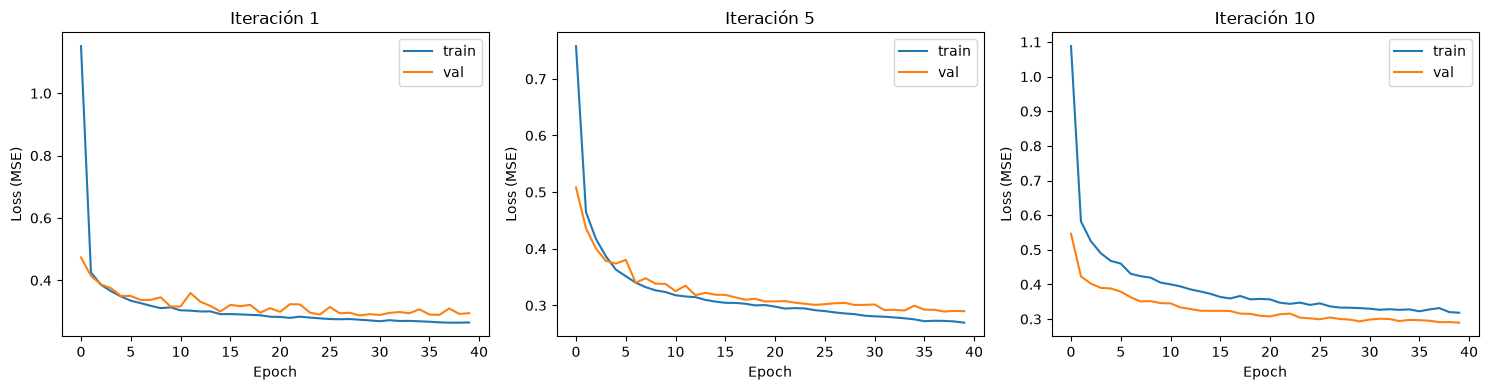

In [21]:
plot_ids = [1, 5, 10]  # números de iteración (1-based)

fig, axes = plt.subplots(1, len(plot_ids), figsize=(15, 4))
for ax, run_id in zip(axes, plot_ids):
    h = histories[run_id - 1]
    ax.plot(h["train_loss"], label="train")
    ax.plot(h["val_loss"], label="val")
    ax.set_title(f"Iteración {run_id}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (MSE)")
    ax.legend()
plt.tight_layout()
plt.show()


### Mejor modelo → evaluación única en test

Se elige la configuración con **menor MSE en validación**. El test solo se usa aquí.


In [22]:
best = min(results, key=lambda r: r["mse_val"])
best_model = models[best["id"] - 1]

print("Mejor configuración (según MSE val):")
for k, v in best.items():
    print(f"  {k}: {v}")

test_ds = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1),
)
test_loader = DataLoader(test_ds, batch_size=best["batch_size"], shuffle=False)

best_model.eval()
preds, targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds.append(best_model(xb.to(device)).cpu())
        targets.append(yb)

y_hat = torch.cat(preds).numpy().ravel()
y_true = torch.cat(targets).numpy().ravel()

test_mse = mean_squared_error(y_true, y_hat)
test_mae = mean_absolute_error(y_true, y_hat)
test_rmse = test_mse ** 0.5

print("\nMétricas en TEST (una sola evaluación):")
print(f"  MSE:  {test_mse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")


Mejor configuración (según MSE val):
  id: 2
  hidden: [128, 64]
  activation: relu
  optimizer: adam
  lr: 0.001
  batch_size: 32
  epochs: 40
  dropout: 0.0
  weight_decay: 0.0
  use_batchnorm: False
  mse_val: 0.28584200143814087
  mae_val: 0.3558995723724365
  rmse_val: 0.5346419375976232
  final_train_loss: 0.24785696136589505
  final_val_loss: 0.28584201004385024

Métricas en TEST (una sola evaluación):
  MSE:  0.2809
  MAE:  0.3532
  RMSE: 0.5300


## Parte 5: Documentación de resultados

Tabla resumen generada automáticamente a partir de las iteraciones de la Parte 4.


In [23]:
def format_reg(row):
    parts = []
    if row["dropout"] > 0:
        parts.append(f"dropout={row['dropout']}")
    if row["weight_decay"] > 0:
        parts.append(f"L2/wd={row['weight_decay']}")
    if row["use_batchnorm"]:
        parts.append("BatchNorm")
    return ", ".join(parts) if parts else "—"

summary = pd.DataFrame([
    {
        "#": r["id"],
        "Arquitectura": r["hidden"],
        "Activación": r["activation"],
        "Optimizador / LR": f"{r['optimizer']} / {r['lr']}",
        "Batch / Epochs": f"{r['batch_size']} / {r['epochs']}",
        "Regularización": format_reg(r),
        "MSE (val)": round(r["mse_val"], 4),
        "MAE (val)": round(r["mae_val"], 4),
        "RMSE (val)": round(r["rmse_val"], 4),
    }
    for r in results
])

display(summary)

print("\nMejor fila (MSE val mínimo):")
display(summary.loc[[summary["MSE (val)"].idxmin()]])

print(
    f"\nTest del mejor modelo → "
    f"MSE={test_mse:.4f}, MAE={test_mae:.4f}, RMSE={test_rmse:.4f}"
)


,#,Arquitectura,Activación,Optimizador / LR,Batch / Epochs,Regularización,MSE (val),MAE (val),RMSE (val)
0,1,"[64, 32]",relu,adam / 0.001,32 / 40,—,0.2945,0.3760,0.5427
1,2,"[128, 64]",relu,adam / 0.001,32 / 40,—,0.2858,0.3559,0.5346
2,3,"[64, 64, 32]",relu,adam / 0.001,32 / 40,—,0.3015,0.3661,0.5491
3,4,"[64, 32]",leaky_relu,adam / 0.001,32 / 40,—,0.2890,0.3701,0.5376
4,5,"[64, 32]",tanh,adam / 0.001,32 / 40,—,0.2898,0.3712,0.5383
5,6,"[64, 32]",relu,sgd / 0.01,32 / 40,—,1.3767,0.9171,1.1733
6,7,"[64, 32]",relu,rmsprop / 0.001,32 / 40,—,0.2862,0.3572,0.5350
7,8,"[64, 32]",relu,adam / 0.0001,32 / 40,—,0.3578,0.4192,0.5982
8,9,"[64, 32]",relu,adam / 0.005,32 / 40,—,0.2882,0.3601,0.5369
9,10,"[64, 32]",relu,adam / 0.001,32 / 40,dropout=0.2,0.2896,0.3663,0.5381



Mejor fila (MSE val mínimo):


,#,Arquitectura,Activación,Optimizador / LR,Batch / Epochs,Regularización,MSE (val),MAE (val),RMSE (val)
1,2,"[128, 64]",relu,adam / 0.001,32 / 40,—,0.2858,0.3559,0.5346



Test del mejor modelo → MSE=0.2809, MAE=0.3532, RMSE=0.5300
